In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from skimage.measure import shannon_entropy

In [5]:
dataset_path = r"F:\work\python\image frequency\images"
output_path = r"F:\work\python\image frequency\processed_dataset_1"

os.makedirs(output_path, exist_ok=True)

In [6]:
image_paths = []

for class_name in os.listdir(dataset_path):
    class_folder = os.path.join(dataset_path, class_name)
    
    if os.path.isdir(class_folder):
        for img_name in os.listdir(class_folder):
            image_paths.append(os.path.join(class_folder, img_name))

print("Total Images:", len(image_paths))

Total Images: 1691


In [7]:
data = []

for img_path in tqdm(image_paths):
    
    img = cv2.imread(img_path)
    if img is None:
        continue

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Resize (consistent size)
    gray = cv2.resize(gray, (224, 224))

    # ---- Features ----
    mean_intensity = np.mean(gray)

    edges = cv2.Canny(gray, 100, 200)
    edge_density = np.sum(edges > 0) / edges.size

    entropy = shannon_entropy(gray)

    data.append({
        "path": img_path,
        "intensity": mean_intensity,
        "edge_density": edge_density,
        "entropy": entropy
    })

df = pd.DataFrame(data)
print(df.head())

100%|██████████| 1691/1691 [00:03<00:00, 422.87it/s]

                                                path   intensity  \
0  F:\work\python\image frequency\images\airplane...  175.453105   
1  F:\work\python\image frequency\images\airplane...  192.778779   
2  F:\work\python\image frequency\images\airplane...  150.174187   
3  F:\work\python\image frequency\images\airplane...  132.092096   
4  F:\work\python\image frequency\images\airplane...  142.141841   

   edge_density   entropy  
0      0.073043  7.148957  
1      0.033781  7.052021  
2      0.072166  6.603656  
3      0.112245  7.270476  
4      0.086655  7.020329  


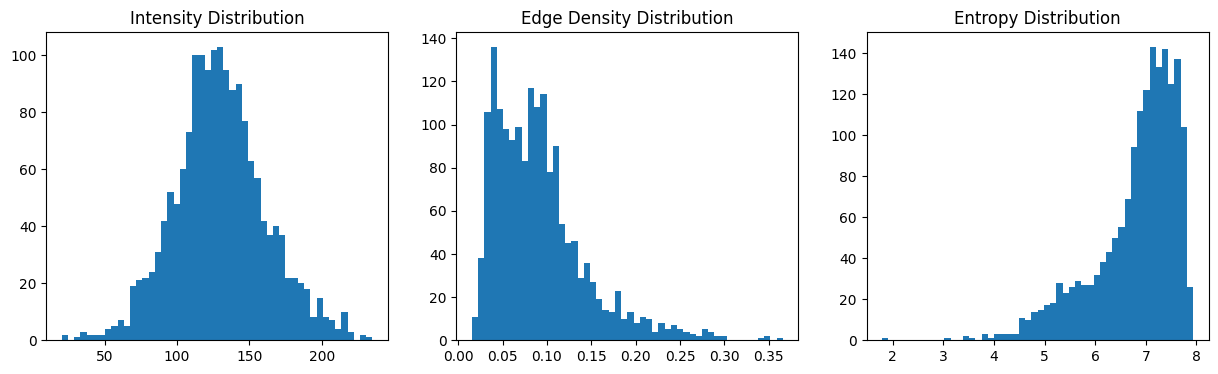

In [8]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.hist(df["intensity"], bins=50)
plt.title("Intensity Distribution")

plt.subplot(1,3,2)
plt.hist(df["edge_density"], bins=50)
plt.title("Edge Density Distribution")

plt.subplot(1,3,3)
plt.hist(df["entropy"], bins=50)
plt.title("Entropy Distribution")

plt.show()

In [9]:
def categorize(row):
    if row["edge_density"] < 0.05:
        return "low"
    elif row["edge_density"] < 0.15:
        return "medium"
    else:
        return "high"

In [10]:
df["category"] = df.apply(categorize, axis=1)

print(df["category"].value_counts())

category
medium    1106
low        393
high       192
Name: count, dtype: int64


In [11]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [12]:
for split in ["train", "test"]:
    for cat in ["low", "medium", "high"]:
        os.makedirs(os.path.join(output_path, split, cat), exist_ok=True)

In [13]:
def save_images(dataframe, split):
    
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        
        img = cv2.imread(row["path"])
        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        gray = cv2.resize(gray, (224, 224))

        filename = os.path.basename(row["path"])
        save_path = os.path.join(output_path, split, row["category"], filename)

        cv2.imwrite(save_path, gray)

In [14]:
save_images(train_df, "train")
save_images(test_df, "test")

100%|██████████| 339/339 [00:00<00:00, 1031.05it/s]


In [15]:
df.to_csv("image_features.csv", index=False)

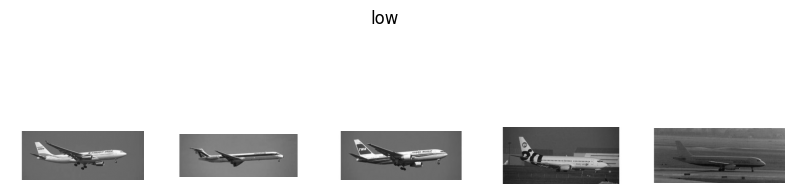

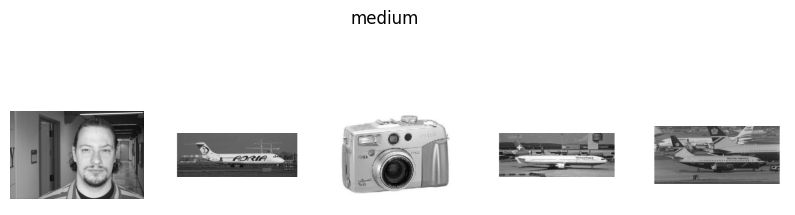

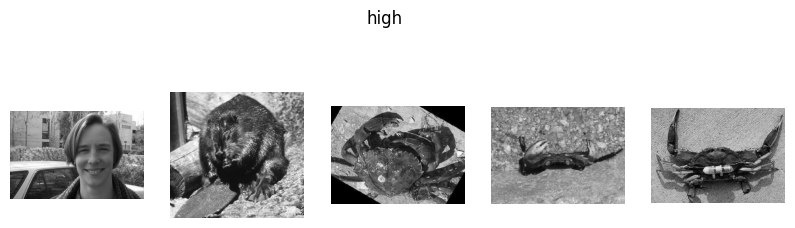

In [16]:
import random
import matplotlib.pyplot as plt

def show_samples(category):
    samples = df[df["category"] == category].sample(5)
    
    plt.figure(figsize=(10,3))
    
    for i, row in enumerate(samples.itertuples()):
        img = cv2.imread(row.path, 0)
        plt.subplot(1,5,i+1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
    
    plt.suptitle(category)
    plt.show()

show_samples("low")
show_samples("medium")
show_samples("high")

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [18]:
def load_dataset(path):
    return tf.keras.preprocessing.image_dataset_from_directory(
        path,
        image_size=(224, 224),
        batch_size=32,
        color_mode='grayscale',
        label_mode='categorical'
    )

In [19]:
def preprocess(ds):
    ds = ds.map(lambda x, y: (x/255.0, y))
    ds = ds.map(lambda x, y: (tf.image.grayscale_to_rgb(x), y))
    return ds.prefetch(buffer_size=tf.data.AUTOTUNE)

In [21]:
low_train = preprocess(load_dataset(r"F:\work\python\image frequency\processed_dataset_1\train\low"))
low_test  = preprocess(load_dataset(r"F:\work\python\image frequency\processed_dataset_1\test\low"))

medium_train = preprocess(load_dataset(r"F:\work\python\image frequency\processed_dataset_1\train\medium"))
medium_test  = preprocess(load_dataset(r"F:\work\python\image frequency\processed_dataset_1\test\medium"))

high_train = preprocess(load_dataset(r"F:\work\python\image frequency\processed_dataset_1\train\high"))
high_test  = preprocess(load_dataset(r"F:\work\python\image frequency\processed_dataset_1\test\high"))

Found 0 files belonging to 0 classes.


ValueError: No images found in directory F:\work\python\image frequency\processed_dataset_1\train\low. Allowed formats: ('.bmp', '.gif', '.jpeg', '.jpg', '.png')